<a href="https://colab.research.google.com/github/code-z4/Signals-and-control-Coursework/blob/main/ELE2038_Lab_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install control

import sympy as sym
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 7.7 MB/s eta 0:00:00


In [2]:
# Define symbols

M, m, ell, g = sym.symbols('M m l g', positive =True)
F, x3, x4 = sym.symbols('F x3 x4', real=True)
s3 = sym.sin(x3)
c3 = sym.cos(x3)


In [3]:
psi = -3 * (m*ell*x4**2*s3*c3 + F*c3 - (M+m)*g*s3)/ ((4*(M+m) - 3*m*(sym.cos(x3)**2)) * ell)
psi

(-3*F*cos(x3) + 3*g*(M + m)*sin(x3) - 3*l*m*x4**2*sin(x3)*cos(x3))/(l*(4*M - 3*m*cos(x3)**2 + 4*m))

In [7]:
d_psi_F = psi.diff(F)
d_psi_x3 = psi.diff(x3)
d_psi_x4 = psi.diff(x4)
d_psi_F

-3*cos(x3)/(l*(4*M - 3*m*cos(x3)**2 + 4*m))

In [8]:
psi0 = psi.subs([(F, 0),(x3, 0),(x4, 0)])
sym.simplify(psi0)

0

In [9]:
d_psi_F_eq= d_psi_F.subs([(F, 0),(x3, 0),(x4, 0)])
d_psi_x3_eq= d_psi_x3.subs([(F, 0),(x3, 0),(x4, 0)])
d_psi_x4_eq= d_psi_x4.subs([(F, 0),(x3, 0),(x4, 0)])
d_psi_F_eq

-3/(l*(4*M + m))

In [10]:
d_psi_x3_eq

3*g*(M + m)/(l*(4*M + m))

In [11]:
d_psi_x4_eq

0

In [13]:
phi = (4*m*ell*x4**2*s3 + 4*F - 3*m*g*s3*c3) / (4*(M+m) - 3*m*(sym.cos(x3)**2))

phi

(4*F - 3*g*m*sin(x3)*cos(x3) + 4*l*m*x4**2*sin(x3))/(4*M - 3*m*cos(x3)**2 + 4*m)

In [14]:
d_phi_F = phi.diff(F)
d_phi_x3 = phi.diff(x3)
d_phi_x4 = phi.diff(x4)

d_phi_F_eq = d_phi_F.subs([(F,0),(x3,0),(x4,0)])
d_phi_x3_eq = d_phi_x3.subs([(F,0),(x3,0),(x4,0)])
d_phi_x4_eq = d_phi_x4.subs([(F,0),(x3,0),(x4,0)])

d_phi_F_eq

4/(4*M + m)

In [15]:
d_phi_x3_eq

-3*g*m/(4*M + m)

In [16]:
d_phi_x4_eq

0

In [17]:
c, d, t = sym.symbols('c, d, t', positive=True)
s = sym.symbols('s')
Gtheta = -c/(s**2 - d)
F = 1
X3 = Gtheta * F
x3 = sym.inverse_laplace_transform(X3, s, t)
x3

-c*sinh(sqrt(d)*t)/sqrt(d)

In [18]:
c, d, t = sym.symbols('c, d, t', positive=True)
s = sym.symbols('s')
Gtheta = -c/(s**2 - d)
F = 1 / s
X3 = Gtheta * F
x3 = sym.inverse_laplace_transform(X3, s, t)
x3

-c*(cosh(sqrt(d)*t)/d - 1/d)

In [19]:
M = 0.3
m =  0.1
ell = 0.35
g = 9.81
c = 3/ell/(4*M+m)
d = (3*(M+m)*g) /(ell*(4*M+m))
c , d

(6.593406593406593, 25.87252747252748)

In [20]:
print(c)
s = ctrl.TransferFunction.s
G = -c / (s**2 - d)

print(G)

6.593406593406593
<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    -6.593
  -----------
  s^2 - 25.87


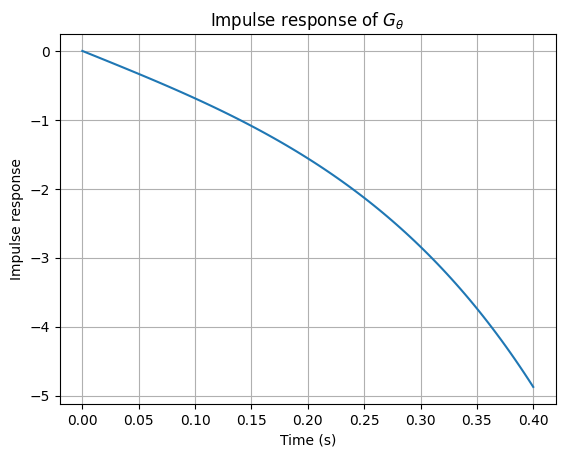

In [21]:
T = np.linspace(0, 0.4, 100)

out = ctrl.impulse_response(G, T)

plt.plot(out.time, out.y[0].T)

plt.xlabel('Time (s)')
plt.ylabel('Impulse response')
plt.title(r'Impulse response of $G_{\theta}$')

plt.grid()
plt.show()

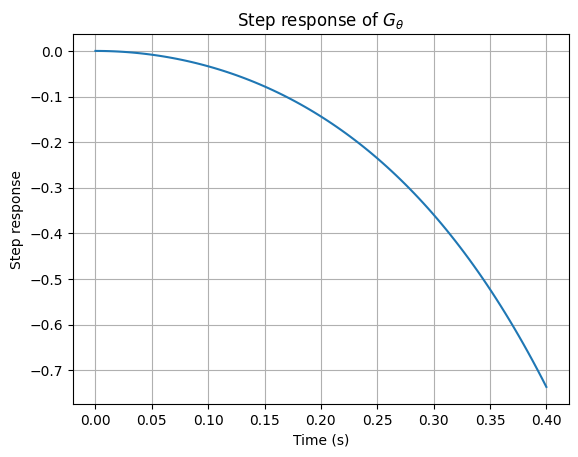

In [22]:
T = np.linspace(0, 0.4, 100)

out = ctrl.step_response(G, T)

plt.plot(out.time, out.y[0].T)

plt.xlabel('Time (s)')
plt.ylabel('Step response')
plt.title(r'Step response of $G_{\theta}$')

plt.grid()
plt.show()

In [23]:
a = 4 / (4*M + m)
b = (3*m*g) / (4*M + m)

Gx = a/(s**2) - (b/(s**2))*G

print(Gx)

<TransferFunction>: sys[21]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  3.077 s^4 - 64.68 s^2
  ---------------------
     s^6 - 25.87 s^4


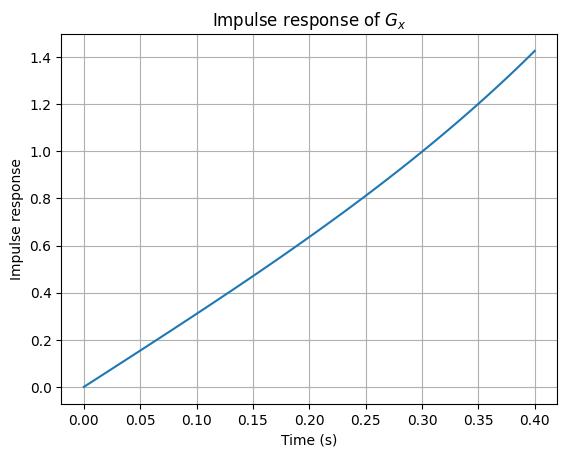

In [24]:
T = np.linspace(0, 0.4, 100)

out = ctrl.impulse_response(Gx, T)

plt.plot(out.time, out.y[0].T)

plt.xlabel('Time (s)')
plt.ylabel('Impulse response')
plt.title(r'Impulse response of $G_x$')

plt.grid()
plt.show()

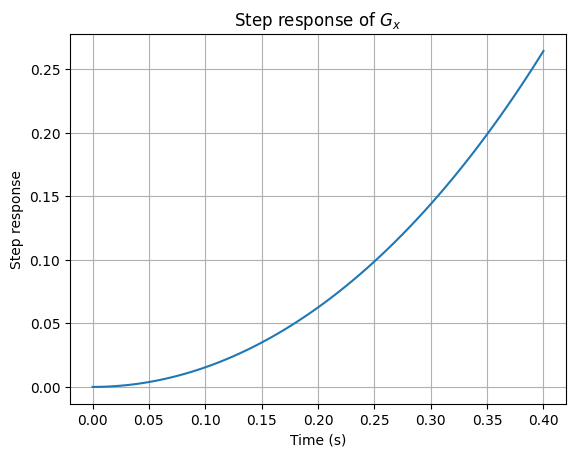

In [25]:
T = np.linspace(0, 0.4, 100)

out = ctrl.step_response(Gx, T)

plt.plot(out.time, out.y[0].T)

plt.xlabel('Time (s)')
plt.ylabel('Step response')
plt.title(r'Step response of $G_x$')

plt.grid()
plt.show()

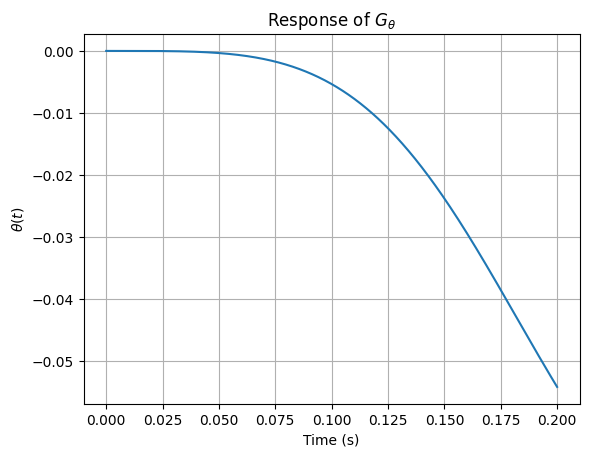

In [26]:
T = np.linspace(0, 0.2, 1000)

F = np.sin(100*T**2)

out_theta = ctrl.forced_response(G, T, F)

plt.plot(out_theta.time, out_theta.outputs)

plt.xlabel('Time (s)')
plt.ylabel(r'$\theta(t)$')

plt.title(r'Response of $G_{\theta}$')

plt.grid()
plt.show()

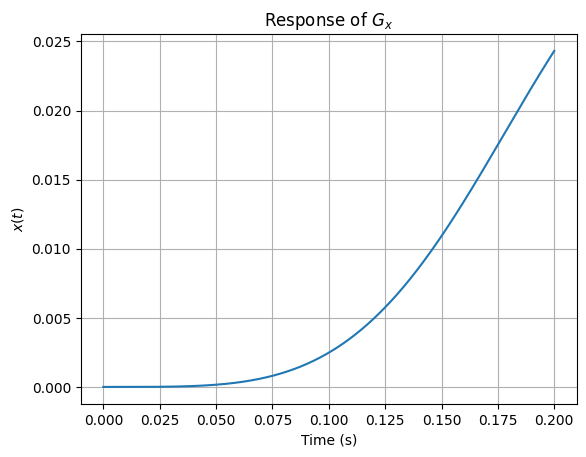

In [27]:
out_x = ctrl.forced_response(Gx, T, F)

plt.plot(out_x.time, out_x.outputs)

plt.xlabel('Time (s)')
plt.ylabel(r'$x(t)$')

plt.title(r'Response of $G_x$')

plt.grid()
plt.show()

<TransferFunction>: sys[61]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

   -6.593
  ---------
  s^2 + 106


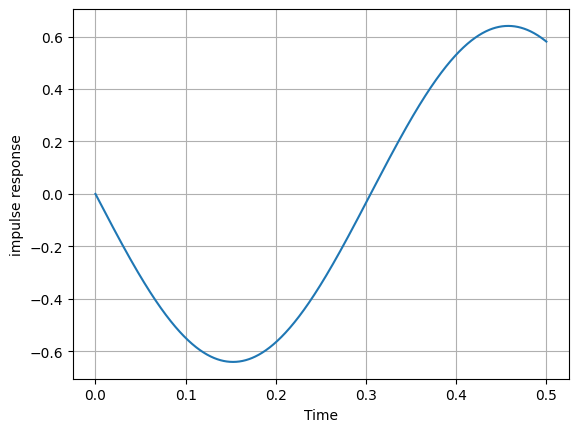

In [31]:
Kc = -20
tau_I = 5
tau_D = 0
Gc = Kc * (1 + tau_D * s)
G_load = ctrl.feedback(G, Gc)
print(G_load)

T = np.linspace(0, 0.5, 1000)
out = ctrl.impulse_response(G_load, T)
plt.plot(out.time, out.y[0].T)

plt.xlabel('Time')
plt.ylabel('impulse response')
plt.grid()

<TransferFunction>: sys[69]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         -6.593
  ---------------------
  s^2 + 46.15 s + 204.9


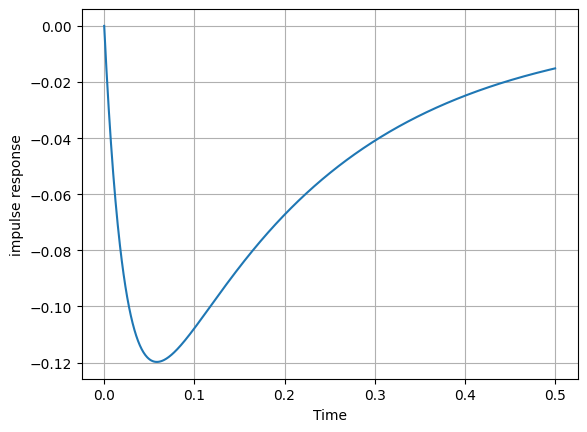

In [32]:
Kc = -35
tau_I = 3
tau_D = 0.2
Gc = Kc * (1 + tau_D * s)
G_load = ctrl.feedback(G, Gc)
print(G_load)

T = np.linspace(0, 0.5, 1000)
out = ctrl.impulse_response(G_load, T)
plt.plot(out.time, out.y[0].T)

plt.xlabel('Time')
plt.ylabel('impulse response')
plt.grid()

<TransferFunction>: sys[77]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         -6.593
  ---------------------
  s^2 + 89.01 s + 270.8


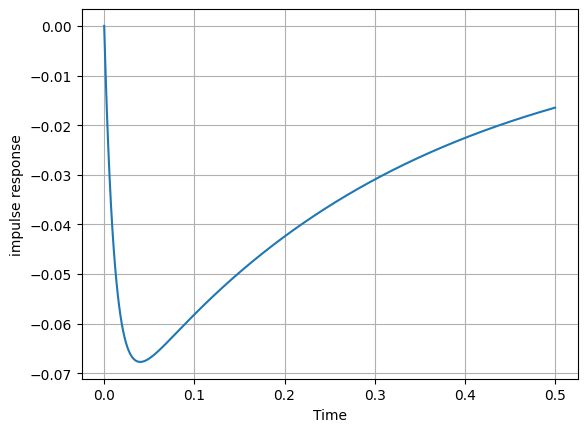

In [33]:
Kc = -45
tau_I = 4
tau_D = 0.3
Gc = Kc * (1 + tau_D * s)
G_load = ctrl.feedback(G, Gc)
print(G_load)

T = np.linspace(0, 0.5, 1000)
out = ctrl.impulse_response(G_load, T)
plt.plot(out.time, out.y[0].T)

plt.xlabel('Time')
plt.ylabel('impulse response')
plt.grid()

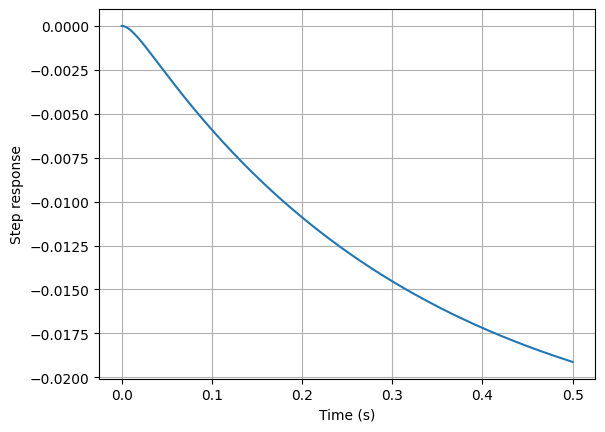

In [34]:
T = np.linspace(0, 0.5, 1000)

D = np.ones(len(T))

out = ctrl.forced_response(G_load, T, D)

plt.plot(out.time, out.outputs)

plt.xlabel('Time (s)')
plt.ylabel('Step response')

plt.grid()
plt.show()

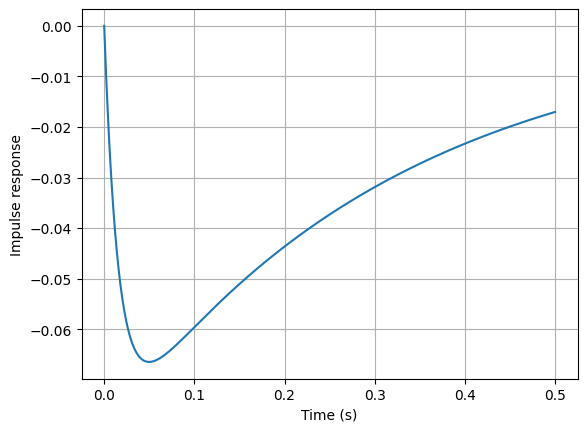

In [35]:
M2 = 0.35
m2 = 0.12
ell2 = 0.4

c2 = 3/ell2/(4*M2+m2)
d2 = (3*(M2+m2)*g)/(ell2*(4*M2+m2))

G2 = -c2/(s**2-d2)

G_load2 = ctrl.feedback(G2, Gc)

T = np.linspace(0, 0.5, 1000)

out = ctrl.impulse_response(G_load2, T)

plt.plot(out.time, out.y[0].T)

plt.xlabel('Time (s)')
plt.ylabel('Impulse response')

plt.grid()
plt.show()